In [ ]:
# ══════════════════════════════════════════════════════════════════
# Section 4.7: Generative Validation — New Dice for Clarinet (v12)
# Apply same analysis pipeline to generated MIDI files
# Compare ONLY to Mozart K.516f (paper values)
# ══════════════════════════════════════════════════════════════════

!pip install music21 ruptures -q

import os
import numpy as np
import ruptures as rpt
from music21 import converter

from google.colab import drive
drive.mount('/content/drive')

GENERATED_DIR = '/content/drive/MyDrive/NEWDiceForClarinet/output/v12_moving_box'

# Paper constants (fixed reference)
SIGMA_MOZART  = 0.822
RAW_VL_MOZART = 2.143
TYMO_MOZART   = 0.508
GPELT_MOZART  = 0.019

# ── Helpers ──────────────────────────────────────────────────────
def pitch_class_histogram(m):
    hist = np.zeros(12)
    for n in m.flatten().notes:
        if hasattr(n, 'pitch'):
            hist[n.pitch.midi % 12] += 1
    if hist.sum() > 0:
        hist /= hist.sum()
    return hist

def corpus_spread(histograms):
    if len(histograms) == 0:
        return 0.0
    arr = np.array(histograms)
    centroid = arr.mean(axis=0)
    if centroid.sum() > 0:
        centroid /= centroid.sum()
    return float(np.mean([np.sum(np.abs(h - centroid)) for h in arr]))

def compute_raw_vl(m):
    pitches = [n.pitch.midi for n in m.flatten().notes
               if hasattr(n, 'pitch')]
    if len(pitches) < 2:
        return 0.0
    return sum(abs(pitches[i+1]-pitches[i])
               for i in range(len(pitches)-1)) / len(pitches)

def compute_tymo_vl(m):
    pitches = [n.pitch.midi for n in m.flatten().notes
               if hasattr(n, 'pitch')]
    if len(pitches) < 2:
        return 0.0
    deltas = [abs((pitches[i] % 12) - (pitches[i+1] % 12))
              for i in range(len(pitches)-1)]
    return sum(min(d, 12-d) for d in deltas) / len(pitches)

def gpelt_density(mean_pitches, pen=3):
    if len(mean_pitches) < 6:
        return 0.0
    signal = np.array(mean_pitches).reshape(-1, 1)
    try:
        algo   = rpt.Pelt(model='rbf', min_size=2).fit(signal)
        breaks = algo.predict(pen=pen)
        return len([b for b in breaks if b < len(mean_pitches)]) / len(mean_pitches)
    except:
        return 0.0

# ── Per-piece analysis ────────────────────────────────────────────
def analyze_piece(midi_path):
    score = converter.parse(midi_path)
    part  = score.parts[0]

    hists       = []
    raw_vls     = []
    tymo_vls    = []
    mean_pitches = []

    for m in part.getElementsByClass('Measure'):
        notes = list(m.flatten().notes)
        if len(notes) < 2:
            continue
        h = pitch_class_histogram(m)
        if h.sum() > 0:
            hists.append(h)
        raw_vls.append(compute_raw_vl(m))
        tymo_vls.append(compute_tymo_vl(m))
        pitches = [n.pitch.midi for n in notes if hasattr(n, 'pitch')]
        if pitches:
            mean_pitches.append(np.mean(pitches))

    return {
        'sigma':    corpus_spread(hists),
        'raw_vl':   np.mean(raw_vls)  if raw_vls  else 0.0,
        'tymo_vl':  np.mean(tymo_vls) if tymo_vls else 0.0,
        'gpelt':    gpelt_density(mean_pitches),
        'n_meas':   len(hists),
    }

# ── Run on all MIDI files ─────────────────────────────────────────
print(f"Analyzing: {GENERATED_DIR}\n")
mid_files = sorted([f for f in os.listdir(GENERATED_DIR)
                    if f.endswith('.mid')])
print(f"Found {len(mid_files)} MIDI files\n")
print(f"  {'File':<45} {'σ':>6}  {'RawVL':>6}  {'TymoVL':>7}  {'GPELT':>6}  {'N':>4}")
print(f"  {'─'*75}")

results = []
for fname in mid_files:
    fpath = os.path.join(GENERATED_DIR, fname)
    try:
        r = analyze_piece(fpath)
        results.append(r)
        print(f"  {fname:<45} {r['sigma']:>6.3f}  {r['raw_vl']:>6.3f}  "
              f"{r['tymo_vl']:>7.3f}  {r['gpelt']:>6.3f}  {r['n_meas']:>4}")
    except Exception as e:
        print(f"  ERR {fname}: {e}")

# ── Aggregate ─────────────────────────────────────────────────────
if results:
    print(f"\n{'═'*60}")
    print(f"  {'Corpus':<30} {'σ':>6}  {'RawVL':>6}  {'TymoVL':>7}  {'GPELT':>6}")
    print(f"  {'─'*55}")
    print(f"  {'Mozart K.516f (paper)':<30} "
          f"{SIGMA_MOZART:>6.3f}  {RAW_VL_MOZART:>6.3f}  "
          f"{TYMO_MOZART:>7.3f}  {GPELT_MOZART:>6.3f}  ← paper")
    print(f"  {'New Dice (v12, N pieces)':<30} "
          f"{np.mean([r['sigma']   for r in results]):>6.3f}  "
          f"{np.mean([r['raw_vl']  for r in results]):>6.3f}  "
          f"{np.mean([r['tymo_vl'] for r in results]):>7.3f}  "
          f"{np.mean([r['gpelt']   for r in results]):>6.3f}  ← NEW")
    print(f"  {'─'*55}")
    print(f"\n  N pieces analyzed: {len(results)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.9 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Analyzing: /content/drive/MyDrive/NEWDiceForClarinet/output/v12_moving_box

Found 5 MIDI files

  File                                               σ   RawVL   TymoVL   GPELT     N
  ───────────────────────────────────────────────────────────────────────────
  clarinet_v12_movingbox_rank01_seed00_d0.000.mid  1.021  10.043    1.073   0.000    20
  clarinet_v12_movingbox_rank02_seed01_d0.000.mid  0.874  11.455    1.241   0.000    18
  clarinet_v12_movingbox_rank03_seed02_d0.000.mid  0.950  11.332    1.417   0.000    21
  clarinet_v12_movingbox_rank04_seed03_d0.000.mid  1.042  11.641    1.250   0.000    17
  clarinet_v12_movingbox_rank05_seed04_d0.000.mid  0.957  11.243    1.399   0.000    19

════════════════════════════════════════════════════════════
  Corpus                        

In [ ]:
# ══════════════════════════════════════════════════════════════════
# Section 4.7: Generative Validation — New Dice v12 soft filter
# Three threshold versions: 0.95, 0.85, 0.75
# ══════════════════════════════════════════════════════════════════

import os
import numpy as np
import ruptures as rpt
from music21 import converter

BASE_DIR = '/content/drive/MyDrive/NEWDiceForClarinet/output/v12_soft_filter'

SIGMA_MOZART  = 0.822
RAW_VL_MOZART = 2.143
TYMO_MOZART   = 0.508
GPELT_MOZART  = 0.019

# ── Helpers ───────────────────────────────────────────────────────
def pitch_class_histogram(m):
    hist = np.zeros(12)
    for n in m.flatten().notes:
        if hasattr(n, 'pitch'):
            hist[n.pitch.midi % 12] += 1
    if hist.sum() > 0:
        hist /= hist.sum()
    return hist

def corpus_spread(histograms):
    if len(histograms) == 0:
        return 0.0
    arr = np.array(histograms)
    centroid = arr.mean(axis=0)
    if centroid.sum() > 0:
        centroid /= centroid.sum()
    return float(np.mean([np.sum(np.abs(h - centroid)) for h in arr]))

def compute_raw_vl(m):
    pitches = [n.pitch.midi for n in m.flatten().notes
               if hasattr(n, 'pitch')]
    if len(pitches) < 2:
        return 0.0
    return sum(abs(pitches[i+1]-pitches[i])
               for i in range(len(pitches)-1)) / len(pitches)

def compute_tymo_vl(m):
    pitches = [n.pitch.midi for n in m.flatten().notes
               if hasattr(n, 'pitch')]
    if len(pitches) < 2:
        return 0.0
    deltas = [abs((pitches[i] % 12) - (pitches[i+1] % 12))
              for i in range(len(pitches)-1)]
    return sum(min(d, 12-d) for d in deltas) / len(pitches)

def gpelt_density(mean_pitches, pen=3):
    if len(mean_pitches) < 6:
        return 0.0
    signal = np.array(mean_pitches).reshape(-1, 1)
    try:
        algo   = rpt.Pelt(model='rbf', min_size=2).fit(signal)
        breaks = algo.predict(pen=pen)
        return len([b for b in breaks if b < len(mean_pitches)]) / len(mean_pitches)
    except:
        return 0.0

def analyze_piece(midi_path):
    score = converter.parse(midi_path)
    part  = score.parts[0]
    hists, raw_vls, tymo_vls, mean_pitches = [], [], [], []
    for m in part.getElementsByClass('Measure'):
        notes = list(m.flatten().notes)
        if len(notes) < 2:
            continue
        h = pitch_class_histogram(m)
        if h.sum() > 0:
            hists.append(h)
        raw_vls.append(compute_raw_vl(m))
        tymo_vls.append(compute_tymo_vl(m))
        pitches = [n.pitch.midi for n in notes if hasattr(n, 'pitch')]
        if pitches:
            mean_pitches.append(np.mean(pitches))
    return {
        'sigma':   corpus_spread(hists),
        'raw_vl':  np.mean(raw_vls)  if raw_vls  else 0.0,
        'tymo_vl': np.mean(tymo_vls) if tymo_vls else 0.0,
        'gpelt':   gpelt_density(mean_pitches),
        'n_meas':  len(hists),
    }

# ── Run per threshold subfolder ───────────────────────────────────
all_summary = {}

for subfolder in sorted(os.listdir(BASE_DIR)):
    subpath = os.path.join(BASE_DIR, subfolder)
    if not os.path.isdir(subpath):
        continue

    mid_files = sorted([f for f in os.listdir(subpath)
                        if f.endswith('.mid')])
    if not mid_files:
        continue

    print(f"\n{'='*65}")
    print(f"  {subfolder}  ({len(mid_files)} files)")
    print(f"  {'-'*60}")
    print(f"  {'File':<45} {'s':>6}  {'RawVL':>6}  {'TymoVL':>7}  {'GPELT':>6}")
    print(f"  {'-'*60}")

    results = []
    for fname in mid_files:
        fpath = os.path.join(subpath, fname)
        try:
            r = analyze_piece(fpath)
            results.append(r)
            print(f"  {fname:<45} {r['sigma']:>6.3f}  {r['raw_vl']:>6.3f}  "
                  f"{r['tymo_vl']:>7.3f}  {r['gpelt']:>6.3f}")
        except Exception as e:
            print(f"  ERR {fname}: {e}")

    if results:
        all_summary[subfolder] = {
            'sigma':   np.mean([r['sigma']   for r in results]),
            'raw_vl':  np.mean([r['raw_vl']  for r in results]),
            'tymo_vl': np.mean([r['tymo_vl'] for r in results]),
            'gpelt':   np.mean([r['gpelt']   for r in results]),
            'n':       len(results),
        }

# ── Final comparison ──────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  {'Corpus':<35} {'s':>6}  {'RawVL':>6}  {'TymoVL':>7}  {'GPELT':>6}")
print(f"  {'-'*65}")
print(f"  {'Mozart K.516f (paper)':<35} "
      f"{SIGMA_MOZART:>6.3f}  {RAW_VL_MOZART:>6.3f}  "
      f"{TYMO_MOZART:>7.3f}  {GPELT_MOZART:>6.3f}  <- paper")

for name, s in all_summary.items():
    label = f"New Dice {name} (N={s['n']})"
    print(f"  {label:<35} "
          f"{s['sigma']:>6.3f}  {s['raw_vl']:>6.3f}  "
          f"{s['tymo_vl']:>7.3f}  {s['gpelt']:>6.3f}")

print(f"  {'-'*65}")


  thr75  (3 files)
  ------------------------------------------------------------
  File                                               s   RawVL   TymoVL   GPELT
  ------------------------------------------------------------
  v12_thr75_rank01_seed00_d0.000.mid             0.915  12.112    1.401   0.000
  v12_thr75_rank02_seed01_d0.000.mid             0.915  12.109    1.501   0.000
  v12_thr75_rank03_seed02_d0.000.mid             0.983  11.978    1.287   0.000

  thr85  (3 files)
  ------------------------------------------------------------
  File                                               s   RawVL   TymoVL   GPELT
  ------------------------------------------------------------
  v12_thr85_rank01_seed00_d0.000.mid             1.009  11.530    1.342   0.000
  v12_thr85_rank02_seed01_d0.000.mid             1.009  11.094    1.156   0.000
  v12_thr85_rank03_seed02_d0.000.mid             0.896  11.250    1.380   0.000

  thr95  (3 files)
  ----------------------------------------------

In [ ]:
# ══════════════════════════════════════════════════════════════════
# Download Mozart Piano Sonata MIDI files from KernScores
# Target: all movements, all 18 piano sonatas
# Output: /content/drive/MyDrive/NEWDiceForClarinet/mozart_piano_sonatas/
# ══════════════════════════════════════════════════════════════════

import os
import time
import requests
from google.colab import drive

drive.mount('/content/drive')

OUT_DIR  = '/content/drive/MyDrive/NEWDiceForClarinet/mozart_piano_sonatas'
BASE_URL = 'https://kern.humdrum.org/cgi-bin/ksdata'
LOCATION = 'musedata/mozart/piano/sonata'

os.makedirs(OUT_DIR, exist_ok=True)

# All 18 Mozart piano sonatas with their movements
SONATAS = [
    ('k279', 3, 'Sonata_1_C_major'),
    ('k280', 3, 'Sonata_2_F_major'),
    ('k281', 3, 'Sonata_3_Bb_major'),
    ('k282', 3, 'Sonata_4_Eb_major'),
    ('k283', 3, 'Sonata_5_G_major'),
    ('k284', 3, 'Sonata_6_D_major'),
    ('k309', 3, 'Sonata_7_C_major'),
    ('k310', 3, 'Sonata_8_a_minor'),
    ('k311', 3, 'Sonata_9_D_major'),
    ('k330', 3, 'Sonata_10_C_major'),
    ('k331', 3, 'Sonata_11_A_major'),
    ('k332', 3, 'Sonata_12_F_major'),
    ('k333', 3, 'Sonata_13_Bb_major'),
    ('k457', 3, 'Sonata_14_c_minor'),
    ('k533', 3, 'Sonata_15_F_major'),
    ('k545', 3, 'Sonata_16_C_major'),
    ('k570', 3, 'Sonata_17_Bb_major'),
    ('k576', 3, 'Sonata_18_D_major'),
]

print(f"Downloading Mozart Piano Sonata MIDI files...\n")

success = []
failed  = []

for k, n_mvt, desc in SONATAS:
    for mvt in range(1, n_mvt + 1):
        filename = f'{k}-0{mvt}.mid'
        filepath = os.path.join(OUT_DIR, filename)

        if os.path.exists(filepath):
            print(f"  SKIP  {filename}")
            success.append(filename)
            continue

        url = (f'{BASE_URL}?location={LOCATION}'
               f'&file={k}-0{mvt}.krn&format=midi')

        try:
            r = requests.get(url, timeout=15)
            if r.status_code == 200 and len(r.content) > 100:
                with open(filepath, 'wb') as f:
                    f.write(r.content)
                kb = len(r.content) // 1024
                print(f"  OK    {filename}  ({kb}KB)  {desc} mvt{mvt}")
                success.append(filename)
            else:
                print(f"  FAIL  {filename}  status={r.status_code}")
                failed.append((filename, r.status_code))
        except Exception as e:
            print(f"  ERR   {filename}  {e}")
            failed.append((filename, str(e)))

        time.sleep(0.4)

print(f"\n{'='*50}")
print(f"Downloaded: {len(success)} / {sum(n for _, n, _ in SONATAS)}")
if failed:
    print(f"Failed:     {len(failed)}")
    for f, reason in failed:
        print(f"  {f}: {reason}")
print(f"\nSaved to: {OUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

  OK    k279-01.mid  (0KB)  Sonata_1_C_major mvt1
  OK    k279-02.mid  (0KB)  Sonata_1_C_major mvt2
  OK    k279-03.mid  (0KB)  Sonata_1_C_major mvt3
  OK    k280-01.mid  (0KB)  Sonata_2_F_major mvt1
  OK    k280-02.mid  (0KB)  Sonata_2_F_major mvt2
  OK    k280-03.mid  (0KB)  Sonata_2_F_major mvt3
  OK    k281-01.mid  (0KB)  Sonata_3_Bb_major mvt1
  OK    k281-02.mid  (0KB)  Sonata_3_Bb_major mvt2
  OK    k281-03.mid  (0KB)  Sonata_3_Bb_major mvt3
  OK    k282-01.mid  (0KB)  Sonata_4_Eb_major mvt1
  OK    k282-02.mid  (0KB)  Sonata_4_Eb_major mvt2
  OK    k282-03.mid  (0KB)  Sonata_4_Eb_major mvt3
  OK    k283-01.mid  (0KB)  Sonata_5_G_major mvt1
  OK    k283-02.mid  (0KB)  Sonata_5_G_major mvt2
  OK    k283-03.mid  (0KB)  Sonata_5_G_major mvt3
  OK    k284-01.mid  (0KB)  Sonata_6_D_major mvt1
  OK    k284-02.mid  (0KB)  Sonata_6_D_major mvt2
  OK    k284-0

In [1]:
# [Checking actual file content]
import os

OUT_DIR = '/content/drive/MyDrive/NEWDiceForClarinet/mozart_piano_sonatas'

# [Inspecting file size and previewing the top rows]
fname = 'k279-01.mid'
fpath = os.path.join(OUT_DIR, fname)
size  = os.path.getsize(fpath)
print(f"actual size: {size} bytes")

with open(fpath, 'rb') as f:
    header = f.read(20)
print(f"file header: {header}")


actual size: 184 bytes
file header: b'<html>\n<head>\n<title'


In [ ]:
import requests

#[Testing potential file paths]
candidates = [
    'musedata/mozart/piano/sonata',
    'musedata/mozart/sonata',
    'musedata/mozart/piano',
    'kern/mozart/piano/sonata',
]

for loc in candidates:
    url = f'https://kern.humdrum.org/cgi-bin/ksdata?location={loc}&file=k279-01.krn&format=midi'
    r   = requests.get(url, timeout=10)
    first4 = r.content[:4]
    print(f"{loc:<40} status={r.status_code}  size={len(r.content)}B  header={first4}")

musedata/mozart/piano/sonata             status=200  size=184B  header=b'<htm'
musedata/mozart/sonata                   status=200  size=178B  header=b'<htm'
musedata/mozart/piano                    status=200  size=177B  header=b'<htm'
kern/mozart/piano/sonata                 status=200  size=180B  header=b'<htm'


In [ ]:
# ══════════════════════════════════════════════════════════════════
# Download Mozart Piano Sonata MIDI via GitHub (craigsapp repo)
# Directly parsing KRN files into music21 (Skipping MIDI conversion)
# ══════════════════════════════════════════════════════════════════

import os
import time
import requests
from google.colab import drive

drive.mount('/content/drive')

OUT_DIR  = '/content/drive/MyDrive/NEWDiceForClarinet/mozart_piano_sonatas'
os.makedirs(OUT_DIR, exist_ok=True)

# GitHub raw URL for craigsapp/mozart-piano-sonatas
BASE_URL = 'https://raw.githubusercontent.com/craigsapp/mozart-piano-sonatas/master/kern'

# file identification
print("Checking available files...\n")
r = requests.get('https://api.github.com/repos/craigsapp/mozart-piano-sonatas/contents/kern', timeout=15)
files = [f['name'] for f in r.json() if f['name'].endswith('.krn')]
files.sort()
print(f"Found {len(files)} KRN files:")
for f in files[:10]:
    print(f"  {f}")
print(f"  ...")
for f in files[-5:]:
    print(f"  {f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking available files...

Found 69 KRN files:
  sonata01-1.krn
  sonata01-2.krn
  sonata01-3.krn
  sonata02-1.krn
  sonata02-2.krn
  sonata02-3.krn
  sonata03-1.krn
  sonata03-2.krn
  sonata03-3.krn
  sonata04-1.krn
  ...
  sonata16-2.krn
  sonata16-3.krn
  sonata17-1.krn
  sonata17-2.krn
  sonata17-3.krn


In [ ]:
# ══════════════════════════════════════════════════════════════════
# Download + Analyze Mozart Piano Sonatas (KRN → music21)
# Source: craigsapp/mozart-piano-sonatas on GitHub
# ══════════════════════════════════════════════════════════════════

!pip install music21 ruptures -q

import os
import time
import requests
import numpy as np
import ruptures as rpt
from music21 import converter
from google.colab import drive

drive.mount('/content/drive')

KRN_DIR  = '/content/drive/MyDrive/NEWDiceForClarinet/mozart_piano_sonatas_krn'
BASE_URL = 'https://raw.githubusercontent.com/craigsapp/mozart-piano-sonatas/master/kern'
os.makedirs(KRN_DIR, exist_ok=True)

# Paper constants
SIGMA_MOZART  = 0.822
RAW_VL_MOZART = 2.143
TYMO_MOZART   = 0.508
GPELT_MOZART  = 0.019

# ── Download KRN files ────────────────────────────────────────────
print("Downloading KRN files...\n")
krn_files = [f'sonata{i:02d}-{m}.krn'
             for i in range(1, 24)
             for m in range(1, 4)]

downloaded = []
for fname in krn_files:
    fpath = os.path.join(KRN_DIR, fname)
    if os.path.exists(fpath):
        downloaded.append(fpath)
        continue
    url = f'{BASE_URL}/{fname}'
    r   = requests.get(url, timeout=10)
    if r.status_code == 200 and len(r.content) > 200:
        with open(fpath, 'wb') as f:
            f.write(r.content)
        downloaded.append(fpath)
        print(f"  OK  {fname}  ({len(r.content)//1024}KB)")
    else:
        print(f"  SKIP {fname}  (status={r.status_code})")
    time.sleep(0.2)

print(f"\nTotal: {len(downloaded)} files\n")

# ── Helpers ───────────────────────────────────────────────────────
def pitch_class_histogram(m):
    hist = np.zeros(12)
    for n in m.flatten().notes:
        if hasattr(n, 'pitch'):
            hist[n.pitch.midi % 12] += 1
        elif hasattr(n, 'pitches'):
            for p in n.pitches:
                hist[p.midi % 12] += 1
    if hist.sum() > 0:
        hist /= hist.sum()
    return hist

def corpus_spread(histograms):
    if len(histograms) == 0:
        return 0.0
    arr      = np.array(histograms)
    centroid = arr.mean(axis=0)
    if centroid.sum() > 0:
        centroid /= centroid.sum()
    return float(np.mean([np.sum(np.abs(h - centroid)) for h in arr]))

def compute_raw_vl(m):
    pitches = [n.pitch.midi for n in m.flatten().notes
               if hasattr(n, 'pitch')]
    if len(pitches) < 2:
        return 0.0
    return sum(abs(pitches[i+1]-pitches[i])
               for i in range(len(pitches)-1)) / len(pitches)

def compute_tymo_vl(m):
    pitches = [n.pitch.midi for n in m.flatten().notes
               if hasattr(n, 'pitch')]
    if len(pitches) < 2:
        return 0.0
    deltas = [abs((pitches[i] % 12) - (pitches[i+1] % 12))
              for i in range(len(pitches)-1)]
    return sum(min(d, 12-d) for d in deltas) / len(pitches)

def gpelt_density(mean_pitches, pen=3):
    if len(mean_pitches) < 6:
        return 0.0
    signal = np.array(mean_pitches).reshape(-1, 1)
    try:
        algo   = rpt.Pelt(model='rbf', min_size=2).fit(signal)
        breaks = algo.predict(pen=pen)
        return len([b for b in breaks if b < len(mean_pitches)]) / len(mean_pitches)
    except:
        return 0.0

# ── Analyze all sonata movements ─────────────────────────────────
print("Analyzing piano sonata movements...\n")

all_hists       = []
all_raw_vls     = []
all_tymo_vls    = []
all_mean_pitches = []
file_count      = 0

for fpath in sorted(downloaded):
    fname = os.path.basename(fpath)
    try:
        score = converter.parse(fpath)
        m_hists, m_raw, m_tymo, m_pitches = [], [], [], []

        for part in score.parts:
            for m in part.getElementsByClass('Measure'):
                notes = list(m.flatten().notes)
                if len(notes) < 2:
                    continue
                h = pitch_class_histogram(m)
                if h.sum() > 0:
                    m_hists.append(h)
                    all_hists.append(h)
                m_raw.append(compute_raw_vl(m))
                m_tymo.append(compute_tymo_vl(m))
                pitches = [n.pitch.midi for n in notes
                           if hasattr(n, 'pitch')]
                if pitches:
                    mp = np.mean(pitches)
                    m_pitches.append(mp)
                    all_mean_pitches.append(mp)

        all_raw_vls.extend(m_raw)
        all_tymo_vls.extend(m_tymo)
        file_count += 1
        print(f"  OK  {fname:<22} "
              f"measures={len(m_hists):>4}  "
              f"σ={corpus_spread(m_hists):.3f}  "
              f"rawVL={np.mean(m_raw):.3f}")
    except Exception as e:
        print(f"  ERR {fname}: {e}")

# ── Final results ─────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  {'Corpus':<30} {'σ':>6}  {'RawVL':>6}  {'TymoVL':>7}  {'GPELT':>6}")
print(f"  {'-'*55}")
print(f"  {'Mozart K.516f (paper)':<30} "
      f"{SIGMA_MOZART:>6.3f}  {RAW_VL_MOZART:>6.3f}  "
      f"{TYMO_MOZART:>7.3f}  {GPELT_MOZART:>6.3f}  <- paper")

sigma_sonata = corpus_spread(all_hists)
raw_sonata   = np.mean(all_raw_vls)  if all_raw_vls  else 0.0
tymo_sonata  = np.mean(all_tymo_vls) if all_tymo_vls else 0.0
gpelt_sonata = gpelt_density(all_mean_pitches)

print(f"  {'Mozart Piano Sonatas (all)':<30} "
      f"{sigma_sonata:>6.3f}  {raw_sonata:>6.3f}  "
      f"{tymo_sonata:>7.3f}  {gpelt_sonata:>6.3f}  <- NEW")
print(f"  {'-'*55}")
print(f"\n  Files analyzed: {file_count}")
print(f"  Total measures: {len(all_hists)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

  OK  sonata01-1.krn  (20KB)
  OK  sonata01-2.krn  (13KB)
  OK  sonata01-3.krn  (15KB)
  OK  sonata02-1.krn  (18KB)
  OK  sonata02-2.krn  (9KB)
  OK  sonata02-3.krn  (14KB)
  OK  sonata03-1.krn  (21KB)
  OK  sonata03-2.krn  (12KB)
  OK  sonata03-3.krn  (22KB)
  OK  sonata04-1.krn  (10KB)
  OK  sonata04-2.krn  (8KB)
  OK  sonata04-3.krn  (10KB)
  OK  sonata05-1.krn  (15KB)
  OK  sonata05-2.krn  (11KB)
  OK  sonata05-3.krn  (20KB)
  OK  sonata06-1.krn  (23KB)
  OK  sonata06-2.krn  (14KB)
  SKIP sonata06-3.krn  (status=404)
  OK  sonata07-1.krn  (20KB)
  OK  sonata07-2.krn  (15KB)
  OK  sonata07-3.krn  (34KB)
  OK  sonata08-1.krn  (28KB)
  OK  sonata08-2.krn  (21KB)
  OK  sonata08-3.krn  (19KB)
  OK  sonata09-1.krn  (19KB)
  OK  sonata09-2.krn  (12KB)
  OK  sonata09-3.krn  (33KB)
  OK  sonata10-1.krn  (24KB)
  OK  sonata10-2.krn  (10KB)
  OK  sonata10-3.krn  (2

humdrum.spineParser: WARNING: Error in parsing event ('4r-') at position 155 for spine None: 'Rest' object has no attribute 'pitch'


  OK  sonata16-1.krn         measures= 345  σ=1.210  rawVL=2.534
  OK  sonata16-2.krn         measures= 111  σ=0.831  rawVL=2.652
  OK  sonata16-3.krn         measures= 178  σ=1.003  rawVL=2.267
  OK  sonata17-1.krn         measures= 297  σ=1.092  rawVL=2.460
  OK  sonata17-2.krn         measures= 124  σ=0.901  rawVL=2.348
  OK  sonata17-3.krn         measures= 351  σ=1.091  rawVL=2.350

  Corpus                              σ   RawVL   TymoVL   GPELT
  -------------------------------------------------------
  Mozart K.516f (paper)           0.822   2.143    0.508   0.019  <- paper
  Mozart Piano Sonatas (all)      1.250   2.378    1.594   0.015  <- NEW
  -------------------------------------------------------

  Files analyzed: 49
  Total measures: 11692


In [ ]:
# ══════════════════════════════════════════════════════════════════
# NEW DICE FOR CLARINET — v12 Piano Sonata Source
# Same Moving Box score function, but source pool from piano sonatas
# ══════════════════════════════════════════════════════════════════

!pip install music21 midi2audio pydub ruptures -q
!apt-get install -y fluidsynth ffmpeg -q
!wget -q https://github.com/urish/cinto/raw/master/media/FluidR3_GM.sf2 \
     -O /content/FluidR3_GM.sf2

import os, copy, random
import numpy as np
import ruptures as rpt
from music21 import converter, stream, note, tempo, meter, instrument
from midi2audio import FluidSynth
from pydub import AudioSegment
from google.colab import drive

drive.mount('/content/drive')

KRN_DIR   = '/content/drive/MyDrive/NEWDiceForClarinet/mozart_piano_sonatas_krn'
OUT_PATH  = '/content/drive/MyDrive/NEWDiceForClarinet/output/v12_piano_source'
D_VEC     = '/content/drive/MyDrive/NEWDiceForClarinet/moving_box_d_vector.npy'
SOUNDFONT = '/content/FluidR3_GM.sf2'
os.makedirs(OUT_PATH, exist_ok=True)

# ── Constants from paper ──────────────────────────────────────────
SIGMA_MOZART  = 0.822
MOZART_RAW_VL = 2.143
MOZART_TYMO   = 0.508
GPELT_MOZART  = 0.019

D_MAJOR_PCS      = {2, 4, 6, 7, 9, 11, 1}
D_MAJOR_CENTROID = np.zeros(12)
for pc in D_MAJOR_PCS:
    D_MAJOR_CENTROID[pc] = 1/7

d = np.load(D_VEC)

# ── Free parameters ───────────────────────────────────────────────
ALPHA       = 0.5
BETA        = 0.5
ARC_SCALE   = 0.3
TEMPO_SCALE = 0.80
N_MEASURES  = 16
N_CANDIDATES= 30
THR         = 0.85   # soft D major threshold

SEMITONE_OPTIONS = [-5, -3, -2, -1, 0, 1, 2, 3, 5]
MIN_NOTES        = 3
CLAR_LOW         = 50
CLAR_HIGH        = 91

# ── Helpers ───────────────────────────────────────────────────────
def pitch_class_histogram(m):
    hist = np.zeros(12)
    for n in m.flatten().notes:
        if hasattr(n, 'pitch'):
            hist[n.pitch.midi % 12] += 1
        elif hasattr(n, 'pitches'):
            for p in n.pitches:
                hist[p.midi % 12] += 1
    if hist.sum() > 0:
        hist /= hist.sum()
    return hist

def mean_pitch(m):
    pitches = [n.pitch.midi for n in m.flatten().notes
               if hasattr(n, 'pitch')]
    return float(np.mean(pitches)) if pitches else 60.0

def compute_raw_vl(m):
    pitches = [n.pitch.midi for n in m.flatten().notes
               if hasattr(n, 'pitch')]
    if len(pitches) < 2:
        return 0.0
    return sum(abs(pitches[i+1]-pitches[i])
               for i in range(len(pitches)-1)) / len(pitches)

def compute_tymo_vl(m):
    pitches = [n.pitch.midi for n in m.flatten().notes
               if hasattr(n, 'pitch')]
    if len(pitches) < 2:
        return 0.0
    deltas = [abs((pitches[i] % 12) - (pitches[i+1] % 12))
              for i in range(len(pitches)-1)]
    return sum(min(d2, 12-d2) for d2 in deltas) / len(pitches)

def in_clarinet_range(m, st):
    for n in m.flatten().notes:
        if hasattr(n, 'pitch'):
            if not (CLAR_LOW <= n.pitch.midi + st <= CLAR_HIGH):
                return False
        elif hasattr(n, 'pitches'):
            for p in n.pitches:
                if not (CLAR_LOW <= p.midi + st <= CLAR_HIGH):
                    return False
    return True

def transpose_measure(m, st):
    new_m = stream.Measure()
    for el in m.flatten().notesAndRests:
        try:
            new_m.append(copy.deepcopy(el).transpose(st))
        except:
            pass
    return new_m

def extract_melody(m):
    new_m = stream.Measure()
    for el in m.flatten().notesAndRests:
        if el.isRest:
            new_m.append(copy.deepcopy(el))
        elif hasattr(el, 'pitches') and len(el.pitches) > 1:
            highest = max(el.pitches, key=lambda p: p.midi)
            n2 = note.Note(highest.midi)
            n2.duration = copy.deepcopy(el.duration)
            new_m.append(n2)
        elif hasattr(el, 'pitch'):
            new_m.append(copy.deepcopy(el))
    return new_m

def soft_d_major(m, threshold=THR):
    notes = [n for n in m.flatten().notes if hasattr(n, 'pitch')]
    if not notes:
        return False
    in_key = sum(1 for n in notes if n.pitch.midi % 12 in D_MAJOR_PCS)
    return in_key / len(notes) >= threshold

def moving_box_score(m, arc_i):
    hist       = pitch_class_histogram(m)
    centroid_i = np.clip(D_MAJOR_CENTROID + arc_i, 0, None)
    if centroid_i.sum() > 0:
        centroid_i /= centroid_i.sum()
    tonal   = np.exp(-np.sum(np.abs(hist - centroid_i)) / SIGMA_MOZART)
    raw_vl  = compute_raw_vl(m)
    tymo_vl = compute_tymo_vl(m)
    variety = np.exp(ALPHA * raw_vl  / MOZART_RAW_VL
                   - BETA  * tymo_vl / MOZART_TYMO)
    return float(tonal * variety)

def gpelt_density(piece, pen=3):
    signal = np.array([[s['mean_pitch']] for s in piece], dtype=float)
    try:
        algo   = rpt.Pelt(model='rbf', min_size=2).fit(signal)
        breaks = algo.predict(pen=pen)
        return len([b for b in breaks if b < len(piece)]) / len(piece)
    except:
        return 0.5

def apply_psym(selected):
    n       = len(selected)
    pitches = np.array([s['mean_pitch'] for s in selected])
    target  = 0.5 * (np.eye(n) + np.eye(n)[::-1]) @ pitches
    result  = list(selected)
    for i in range(n // 2):
        j    = n - 1 - i
        curr = (abs(result[i]['mean_pitch'] - target[i]) +
                abs(result[j]['mean_pitch'] - target[j]))
        swap = (abs(result[j]['mean_pitch'] - target[i]) +
                abs(result[i]['mean_pitch'] - target[j]))
        if swap < curr:
            result[i], result[j] = result[j], result[i]
    return result

# ── Build pool from piano sonatas ──────────

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
The following additional packages will be installed:
  at-spi2-core fluid-soundfont-gm gsettings-desktop-schemas libatk-bridge2.0-0
  libatk1.0-0 libatk1.0-data libatspi2.0-0 libdouble-conversion3 libevdev2
  libfluidsynth3 libgtk-3-0 libgtk-3-bin libgtk-3-common libgudev-1.0-0
  libinput-bin libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5
  librsvg2-common libwacom-bin libwacom-common libwacom9 libxcb-icccm4
  libxcb-image0 libxcb-keysyms1 libxcb-render-util0 libxcb-util1
  libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1 libxcomposite1
  libxkbcommon-x11-0 libxtst6 qsynth qt5-gtk-platformtheme
  qttranslations5-l10n session-migration timgm6mb-soundfont
Suggested packages:
  fluid-soundfont-gs gvfs qt5-image-formats-plugins qtwayland5 jackd
The following NEW packages

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ══════════════════════════════════════════════════════════════════
# NEW DICE FOR CLARINET — v12 Piano Sonata Source
# Same Moving Box score function, but source pool from piano sonatas
# ══════════════════════════════════════════════════════════════════

!pip install music21 midi2audio pydub ruptures -q
!apt-get install -y fluidsynth ffmpeg -q
!wget -q https://github.com/urish/cinto/raw/master/media/FluidR3_GM.sf2 \
     -O /content/FluidR3_GM.sf2

import os, copy, random
import numpy as np
import ruptures as rpt
from music21 import converter, stream, note, tempo, meter, instrument
from midi2audio import FluidSynth
from pydub import AudioSegment
from google.colab import drive

drive.mount('/content/drive')

KRN_DIR   = '/content/drive/MyDrive/NEWDiceForClarinet/mozart_piano_sonatas_krn'
OUT_PATH  = '/content/drive/MyDrive/NEWDiceForClarinet/output/v12_piano_source'
D_VEC     = '/content/drive/MyDrive/NEWDiceForClarinet/moving_box_d_vector.npy'
SOUNDFONT = '/content/FluidR3_GM.sf2'
os.makedirs(OUT_PATH, exist_ok=True)

# ── Constants from paper ──────────────────────────────────────────
SIGMA_MOZART  = 0.822
MOZART_RAW_VL = 2.143
MOZART_TYMO   = 0.508
GPELT_MOZART  = 0.019

D_MAJOR_PCS      = {2, 4, 6, 7, 9, 11, 1}
D_MAJOR_CENTROID = np.zeros(12)
for pc in D_MAJOR_PCS:
    D_MAJOR_CENTROID[pc] = 1/7

d = np.load(D_VEC)

# ── Free parameters ───────────────────────────────────────────────
ALPHA       = 0.5
BETA        = 0.5
ARC_SCALE   = 0.3
TEMPO_SCALE = 0.80
N_MEASURES  = 16
N_CANDIDATES= 30
THR         = 0.85   # soft D major threshold

SEMITONE_OPTIONS = [-5, -3, -2, -1, 0, 1, 2, 3, 5]
MIN_NOTES        = 3
CLAR_LOW         = 50
CLAR_HIGH        = 91

# ── Helpers ───────────────────────────────────────────────────────
def pitch_class_histogram(m):
    hist = np.zeros(12)
    for n in m.flatten().notes:
        if hasattr(n, 'pitch'):
            hist[n.pitch.midi % 12] += 1
        elif hasattr(n, 'pitches'):
            for p in n.pitches:
                hist[p.midi % 12] += 1
    if hist.sum() > 0:
        hist /= hist.sum()
    return hist

def mean_pitch(m):
    pitches = [n.pitch.midi for n in m.flatten().notes
               if hasattr(n, 'pitch')]
    return float(np.mean(pitches)) if pitches else 60.0

def compute_raw_vl(m):
    pitches = [n.pitch.midi for n in m.flatten().notes
               if hasattr(n, 'pitch')]
    if len(pitches) < 2:
        return 0.0
    return sum(abs(pitches[i+1]-pitches[i])
               for i in range(len(pitches)-1)) / len(pitches)

def compute_tymo_vl(m):
    pitches = [n.pitch.midi for n in m.flatten().notes
               if hasattr(n, 'pitch')]
    if len(pitches) < 2:
        return 0.0
    deltas = [abs((pitches[i] % 12) - (pitches[i+1] % 12))
              for i in range(len(pitches)-1)]
    return sum(min(d2, 12-d2) for d2 in deltas) / len(pitches)

def in_clarinet_range(m, st):
    for n in m.flatten().notes:
        if hasattr(n, 'pitch'):
            if not (CLAR_LOW <= n.pitch.midi + st <= CLAR_HIGH):
                return False
        elif hasattr(n, 'pitches'):
            for p in n.pitches:
                if not (CLAR_LOW <= p.midi + st <= CLAR_HIGH):
                    return False
    return True

def transpose_measure(m, st):
    new_m = stream.Measure()
    for el in m.flatten().notesAndRests:
        try:
            new_m.append(copy.deepcopy(el).transpose(st))
        except:
            pass
    return new_m

def extract_melody(m):
    new_m = stream.Measure()
    for el in m.flatten().notesAndRests:
        if el.isRest:
            new_m.append(copy.deepcopy(el))
        elif hasattr(el, 'pitches') and len(el.pitches) > 1:
            highest = max(el.pitches, key=lambda p: p.midi)
            n2 = note.Note(highest.midi)
            n2.duration = copy.deepcopy(el.duration)
            new_m.append(n2)
        elif hasattr(el, 'pitch'):
            new_m.append(copy.deepcopy(el))
    return new_m

def soft_d_major(m, threshold=THR):
    notes = [n for n in m.flatten().notes if hasattr(n, 'pitch')]
    if not notes:
        return False
    in_key = sum(1 for n in notes if n.pitch.midi % 12 in D_MAJOR_PCS)
    return in_key / len(notes) >= threshold

def moving_box_score(m, arc_i):
    hist       = pitch_class_histogram(m)
    centroid_i = np.clip(D_MAJOR_CENTROID + arc_i, 0, None)
    if centroid_i.sum() > 0:
        centroid_i /= centroid_i.sum()
    tonal   = np.exp(-np.sum(np.abs(hist - centroid_i)) / SIGMA_MOZART)
    raw_vl  = compute_raw_vl(m)
    tymo_vl = compute_tymo_vl(m)
    variety = np.exp(ALPHA * raw_vl  / MOZART_RAW_VL
                   - BETA  * tymo_vl / MOZART_TYMO)
    return float(tonal * variety)

def gpelt_density(piece, pen=3):
    signal = np.array([[s['mean_pitch']] for s in piece], dtype=float)
    try:
        algo   = rpt.Pelt(model='rbf', min_size=2).fit(signal)
        breaks = algo.predict(pen=pen)
        return len([b for b in breaks if b < len(piece)]) / len(piece)
    except:
        return 0.5

def apply_psym(selected):
    n       = len(selected)
    pitches = np.array([s['mean_pitch'] for s in selected])
    target  = 0.5 * (np.eye(n) + np.eye(n)[::-1]) @ pitches
    result  = list(selected)
    for i in range(n // 2):
        j    = n - 1 - i
        curr = (abs(result[i]['mean_pitch'] - target[i]) +
                abs(result[j]['mean_pitch'] - target[j]))
        swap = (abs(result[j]['mean_pitch'] - target[i]) +
                abs(result[i]['mean_pitch'] - target[j]))
        if swap < curr:
            result[i], result[j] = result[j], result[i]
    return result

# ── Build pool from piano sonatas ─────────────────────────────────
print("Building pool from piano sonata KRN files...\n")
all_raw = []

for fname in sorted(os.listdir(KRN_DIR)):
    if not fname.endswith('.krn'):
        continue
    fpath = os.path.join(KRN_DIR, fname)
    try:
        score = converter.parse(fpath)
        cnt   = 0
        for part in score.parts:
            for m in part.getElementsByClass('Measure'):
                if len(list(m.flatten().notes)) >= MIN_NOTES:
                    all_raw.append((m, fname))
                    cnt += 1
        print(f"  {fname:<22} {cnt} measures")
    except Exception as e:
        print(f"  ERR {fname}: {e}")

print(f"\n  Total raw: {len(all_raw)}")

# ── Apply filters ─────────────────────────────────────────────────
print("\nApplying filters (range + soft D major)...")
pool = []
for m, src in all_raw:
    for st in SEMITONE_OPTIONS:
        if not in_clarinet_range(m, st):
            continue
        transposed = transpose_measure(m, st)
        melody_m   = extract_melody(transposed)
        if len(list(melody_m.flatten().notes)) < MIN_NOTES:
            continue
        if not soft_d_major(melody_m):
            continue
        pool.append({
            'measure':    melody_m,
            'mean_pitch': mean_pitch(melody_m),
            'raw_vl':     compute_raw_vl(melody_m),
            'tymo_vl':    compute_tymo_vl(melody_m),
            'source':     src,
        })

print(f"  Pool: {len(pool)} measures")

# ── Generator ─────────────────────────────────────────────────────
def generate_piece(pool, seed=42):
    random.seed(seed)
    f    = np.array([np.sin(np.pi * i / N_MEASURES)
                     for i in range(N_MEASURES)])
    arcs = [f[i] * ARC_SCALE * d for i in range(N_MEASURES)]

    tempo_base = [63,66,66,68,70,72,76,80,76,72,68,65,62,60,58,56]
    tempo_arc  = [max(40, int(t * TEMPO_SCALE)) for t in tempo_base]
    vel_arc    = [42,52,62,70,75,78,82,86,80,72,64,55,48,42,38,35]

    selected = []
    used_ids = set()
    for i, (bpm, vel, arc_i) in enumerate(zip(tempo_arc, vel_arc, arcs)):
        candidates = [m for m in pool if id(m['measure']) not in used_ids]
        if not candidates:
            candidates = pool
        scored = sorted(candidates,
                        key=lambda m: moving_box_score(m['measure'], arc_i),
                        reverse=True)
        chosen = random.choice(scored[:16])
        for n2 in chosen['measure'].flatten().notes:
            n2.volume.velocity = vel
        selected.append({
            'measure':    chosen['measure'],
            'bpm':        bpm,
            'mean_pitch': chosen['mean_pitch'],
            'raw_vl':     chosen['raw_vl'],
            'tymo_vl':    chosen['tymo_vl'],
        })
        used_ids.add(id(chosen['measure']))
    return apply_psym(selected)

def build_score(selected):
    result = stream.Score()
    part   = stream.Part()
    part.append(instrument.Clarinet())
    part.append(meter.TimeSignature('4/4'))
    prev_bpm = None
    for item in selected:
        if item['bpm'] != prev_bpm:
            part.append(tempo.MetronomeMark(number=item['bpm']))
            prev_bpm = item['bpm']
        part.append(copy.deepcopy(item['measure']))
    result.append(part)
    return result

def render_mp3(score_obj, name):
    midi_path = os.path.join(OUT_PATH, f'{name}.mid')
    wav_path  = os.path.join(OUT_PATH, f'{name}.wav')
    mp3_path  = os.path.join(OUT_PATH, f'{name}.mp3')
    score_obj.write('midi', fp=midi_path)
    FluidSynth(SOUNDFONT).midi_to_audio(midi_path, wav_path)
    audio = (AudioSegment.from_wav(wav_path)
             .fade_in(500).fade_out(3000))
    audio.export(mp3_path, format='mp3', bitrate='192k')
    os.remove(wav_path)
    kb  = os.path.getsize(mp3_path) // 1024
    sec = len(audio) / 1000
    print(f"  OK  {name}.mp3  ({kb}KB, {sec:.1f}s)")

# ── Generate + rank ───────────────────────────────────────────────
print(f"\nGenerating {N_CANDIDATES} candidates...\n")

results = []
for seed in range(N_CANDIDATES):
    piece   = generate_piece(pool, seed=seed)
    density = gpelt_density(piece)
    results.append({
        'seed':    seed,
        'piece':   piece,
        'density': density,
        'raw_vl':  np.mean([s['raw_vl']  for s in piece]),
        'tymo_vl': np.mean([s['tymo_vl'] for s in piece]),
    })

results.sort(key=lambda x: abs(x['density'] - GPELT_MOZART))

print(f"Top 10 candidates:")
print(f"  {'seed':>4}  {'density':>8}  {'raw_VL':>7}  {'tymo_VL':>8}")
print(f"  {'-'*35}")
for r in results[:10]:
    print(f"  {r['seed']:>4}  {r['density']:>8.3f}  "
          f"{r['raw_vl']:>7.3f}  {r['tymo_vl']:>8.3f}")

print(f"\n  Mozart targets: density={GPELT_MOZART}, "
      f"raw_VL={MOZART_RAW_VL}, tymo_VL={TYMO_MOZART}")

# Render top 5
print(f"\nRendering top 5...\n")
for rank, r in enumerate(results[:5]):
    score_obj = build_score(r['piece'])
    name      = (f"v12_piano_rank{rank+1:02d}_seed{r['seed']:02d}"
                 f"_d{r['density']:.3f}")
    render_mp3(score_obj, name)

print(f"\nSaved to: {OUT_PATH}")

Reading package lists...
Building dependency tree...
Reading state information...
fluidsynth is already the newest version (2.2.5-1).
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Building pool from piano sonata KRN files...

  sonata01-1.krn         190 measures
  sonata01-2.krn         128 measures
  sonata01-3.krn         198 measures
  sonata02-1.krn         209 measures
  sonata02-2.krn         100 measures
  sonata02-3.krn         177 measures
  sonata03-1.krn         176 measures
  sonata03-2.krn         152 measures
  sonata03-3.krn         266 measures
  sonata04-1.krn         72 measures
  sonata04-2.krn         106 measures
  sonata04-3.krn         131 measures
  sonata05-1.krn         206 measures
  sonata05-2.krn         81 measures
  sonata05-3.krn         268 meas

In [ ]:
# ══════════════════════════════════════════════════════════════════
# NEW DICE FOR CLARINET — v12 Piano Source (fixed score function)
# Target-proximity scoring instead of reward-maximization
# ══════════════════════════════════════════════════════════════════

!pip install music21 midi2audio pydub ruptures -q
!apt-get install -y fluidsynth ffmpeg -q
!wget -q https://github.com/urish/cinto/raw/master/media/FluidR3_GM.sf2 \
     -O /content/FluidR3_GM.sf2

import os, copy, random
import numpy as np
import ruptures as rpt
from music21 import converter, stream, note, tempo, meter, instrument
from midi2audio import FluidSynth
from pydub import AudioSegment
from google.colab import drive

drive.mount('/content/drive')

KRN_DIR   = '/content/drive/MyDrive/NEWDiceForClarinet/mozart_piano_sonatas_krn'
OUT_PATH  = '/content/drive/MyDrive/NEWDiceForClarinet/output/v12_piano_fixed'
D_VEC     = '/content/drive/MyDrive/NEWDiceForClarinet/moving_box_d_vector.npy'
SOUNDFONT = '/content/FluidR3_GM.sf2'
os.makedirs(OUT_PATH, exist_ok=True)

# ── Constants from paper ──────────────────────────────────────────
SIGMA_MOZART  = 0.822
MOZART_RAW_VL = 2.143
MOZART_TYMO   = 0.508
GPELT_MOZART  = 0.019

D_MAJOR_PCS      = {2, 4, 6, 7, 9, 11, 1}
D_MAJOR_CENTROID = np.zeros(12)
for pc in D_MAJOR_PCS:
    D_MAJOR_CENTROID[pc] = 1/7

d = np.load(D_VEC)

# ── Free parameters ───────────────────────────────────────────────
ALPHA       = 1.0
BETA        = 1.0
ARC_SCALE   = 0.3
TEMPO_SCALE = 0.80
N_MEASURES  = 16
N_CANDIDATES= 30
THR         = 0.85

SEMITONE_OPTIONS = [-5, -3, -2, -1, 0, 1, 2, 3, 5]
MIN_NOTES        = 3
CLAR_LOW         = 50
CLAR_HIGH        = 91

# ── Helpers ───────────────────────────────────────────────────────
def pitch_class_histogram(m):
    hist = np.zeros(12)
    for n in m.flatten().notes:
        if hasattr(n, 'pitch'):
            hist[n.pitch.midi % 12] += 1
        elif hasattr(n, 'pitches'):
            for p in n.pitches:
                hist[p.midi % 12] += 1
    if hist.sum() > 0:
        hist /= hist.sum()
    return hist

def mean_pitch(m):
    pitches = [n.pitch.midi for n in m.flatten().notes
               if hasattr(n, 'pitch')]
    return float(np.mean(pitches)) if pitches else 60.0

def compute_raw_vl(m):
    pitches = [n.pitch.midi for n in m.flatten().notes
               if hasattr(n, 'pitch')]
    if len(pitches) < 2:
        return 0.0
    return sum(abs(pitches[i+1]-pitches[i])
               for i in range(len(pitches)-1)) / len(pitches)

def compute_tymo_vl(m):
    pitches = [n.pitch.midi for n in m.flatten().notes
               if hasattr(n, 'pitch')]
    if len(pitches) < 2:
        return 0.0
    deltas = [abs((pitches[i] % 12) - (pitches[i+1] % 12))
              for i in range(len(pitches)-1)]
    return sum(min(d2, 12-d2) for d2 in deltas) / len(pitches)

def in_clarinet_range(m, st):
    for n in m.flatten().notes:
        if hasattr(n, 'pitch'):
            if not (CLAR_LOW <= n.pitch.midi + st <= CLAR_HIGH):
                return False
        elif hasattr(n, 'pitches'):
            for p in n.pitches:
                if not (CLAR_LOW <= p.midi + st <= CLAR_HIGH):
                    return False
    return True

def transpose_measure(m, st):
    new_m = stream.Measure()
    for el in m.flatten().notesAndRests:
        try:
            new_m.append(copy.deepcopy(el).transpose(st))
        except:
            pass
    return new_m

def extract_melody(m):
    new_m = stream.Measure()
    for el in m.flatten().notesAndRests:
        if el.isRest:
            new_m.append(copy.deepcopy(el))
        elif hasattr(el, 'pitches') and len(el.pitches) > 1:
            highest = max(el.pitches, key=lambda p: p.midi)
            n2 = note.Note(highest.midi)
            n2.duration = copy.deepcopy(el.duration)
            new_m.append(n2)
        elif hasattr(el, 'pitch'):
            new_m.append(copy.deepcopy(el))
    return new_m

def soft_d_major(m, threshold=THR):
    notes = [n for n in m.flatten().notes if hasattr(n, 'pitch')]
    if not notes:
        return False
    in_key = sum(1 for n in notes if n.pitch.midi % 12 in D_MAJOR_PCS)
    return in_key / len(notes) >= threshold

def moving_box_score(m, arc_i):
    hist       = pitch_class_histogram(m)
    centroid_i = np.clip(D_MAJOR_CENTROID + arc_i, 0, None)
    if centroid_i.sum() > 0:
        centroid_i /= centroid_i.sum()

    # Tonal floor (moving)
    tonal = np.exp(-np.sum(np.abs(hist - centroid_i)) / SIGMA_MOZART)

    # Deceptive variety — target proximity (fixed)
    raw_vl  = compute_raw_vl(m)
    tymo_vl = compute_tymo_vl(m)
    raw_score  = np.exp(-ALPHA * abs(raw_vl  - MOZART_RAW_VL) / MOZART_RAW_VL)
    tymo_score = np.exp(-BETA  * abs(tymo_vl - MOZART_TYMO)   / MOZART_TYMO)

    return float(tonal * raw_score * tymo_score)

def gpelt_density(piece, pen=3):
    signal = np.array([[s['mean_pitch']] for s in piece], dtype=float)
    try:
        algo   = rpt.Pelt(model='rbf', min_size=2).fit(signal)
        breaks = algo.predict(pen=pen)
        return len([b for b in breaks if b < len(piece)]) / len(piece)
    except:
        return 0.5

def apply_psym(selected):
    n       = len(selected)
    pitches = np.array([s['mean_pitch'] for s in selected])
    target  = 0.5 * (np.eye(n) + np.eye(n)[::-1]) @ pitches
    result  = list(selected)
    for i in range(n // 2):
        j    = n - 1 - i
        curr = (abs(result[i]['mean_pitch'] - target[i]) +
                abs(result[j]['mean_pitch'] - target[j]))
        swap = (abs(result[j]['mean_pitch'] - target[i]) +
                abs(result[i]['mean_pitch'] - target[j]))
        if swap < curr:
            result[i], result[j] = result[j], result[i]
    return result

# ── Build pool ────────────────────────────────────────────────────
print("Building pool from piano sonata KRN files...\n")
all_raw = []

for fname in sorted(os.listdir(KRN_DIR)):
    if not fname.endswith('.krn'):
        continue
    fpath = os.path.join(KRN_DIR, fname)
    try:
        score = converter.parse(fpath)
        cnt   = 0
        for part in score.parts:
            for m in part.getElementsByClass('Measure'):
                if len(list(m.flatten().notes)) >= MIN_NOTES:
                    all_raw.append((m, fname))
                    cnt += 1
        print(f"  {fname:<22} {cnt} measures")
    except Exception as e:
        print(f"  ERR {fname}: {e}")

print(f"\n  Total raw: {len(all_raw)}")

print("\nApplying filters...")
pool = []
for m, src in all_raw:
    for st in SEMITONE_OPTIONS:
        if not in_clarinet_range(m, st):
            continue
        transposed = transpose_measure(m, st)
        melody_m   = extract_melody(transposed)
        if len(list(melody_m.flatten().notes)) < MIN_NOTES:
            continue
        if not soft_d_major(melody_m):
            continue
        pool.append({
            'measure':    melody_m,
            'mean_pitch': mean_pitch(melody_m),
            'raw_vl':     compute_raw_vl(melody_m),
            'tymo_vl':    compute_tymo_vl(melody_m),
            'source':     src,
        })

print(f"  Pool: {len(pool)} measures")

# Raw VL 분포 확인
raw_vls = [s['raw_vl'] for s in pool]
print(f"\n  Pool raw_vl: mean={np.mean(raw_vls):.3f}  "
      f"<3.0: {sum(1 for v in raw_vls if v < 3.0)}/{len(raw_vls)}")

# ── Generator ─────────────────────────────────────────────────────
def generate_piece(pool, seed=42):
    random.seed(seed)
    f    = np.array([np.sin(np.pi * i / N_MEASURES)
                     for i in range(N_MEASURES)])
    arcs = [f[i] * ARC_SCALE * d for i in range(N_MEASURES)]

    tempo_base = [63,66,66,68,70,72,76,80,76,72,68,65,62,60,58,56]
    tempo_arc  = [max(40, int(t * TEMPO_SCALE)) for t in tempo_base]
    vel_arc    = [42,52,62,70,75,78,82,86,80,72,64,55,48,42,38,35]

    selected = []
    used_ids = set()
    for i, (bpm, vel, arc_i) in enumerate(zip(tempo_arc, vel_arc, arcs)):
        candidates = [m for m in pool if id(m['measure']) not in used_ids]
        if not candidates:
            candidates = pool
        scored = sorted(candidates,
                        key=lambda m: moving_box_score(m['measure'], arc_i),
                        reverse=True)
        chosen = random.choice(scored[:16])
        for n2 in chosen['measure'].flatten().notes:
            n2.volume.velocity = vel
        selected.append({
            'measure':    chosen['measure'],
            'bpm':        bpm,
            'mean_pitch': chosen['mean_pitch'],
            'raw_vl':     chosen['raw_vl'],
            'tymo_vl':    chosen['tymo_vl'],
        })
        used_ids.add(id(chosen['measure']))
    return apply_psym(selected)

def build_score(selected):
    result = stream.Score()
    part   = stream.Part()
    part.append(instrument.Clarinet())
    part.append(meter.TimeSignature('4/4'))
    prev_bpm = None
    for item in selected:
        if item['bpm'] != prev_bpm:
            part.append(tempo.MetronomeMark(number=item['bpm']))
            prev_bpm = item['bpm']
        part.append(copy.deepcopy(item['measure']))
    result.append(part)
    return result

def render_mp3(score_obj, name):
    midi_path = os.path.join(OUT_PATH, f'{name}.mid')
    wav_path  = os.path.join(OUT_PATH, f'{name}.wav')
    mp3_path  = os.path.join(OUT_PATH, f'{name}.mp3')
    score_obj.write('midi', fp=midi_path)
    FluidSynth(SOUNDFONT).midi_to_audio(midi_path, wav_path)
    audio = (AudioSegment.from_wav(wav_path)
             .fade_in(500).fade_out(3000))
    audio.export(mp3_path, format='mp3', bitrate='192k')
    os.remove(wav_path)
    kb  = os.path.getsize(mp3_path) // 1024
    sec = len(audio) / 1000
    print(f"  OK  {name}.mp3  ({kb}KB, {sec:.1f}s)")

# ── Generate + rank ───────────────────────────────────────────────
print(f"\nGenerating {N_CANDIDATES} candidates...\n")

results = []
for seed in range(N_CANDIDATES):
    piece   = generate_piece(pool, seed=seed)
    density = gpelt_density(piece)
    results.append({
        'seed':    seed,
        'piece':   piece,
        'density': density,
        'raw_vl':  np.mean([s['raw_vl']  for s in piece]),
        'tymo_vl': np.mean([s['tymo_vl'] for s in piece]),
    })

results.sort(key=lambda x: abs(x['density'] - GPELT_MOZART))

print(f"Top 10 candidates:")
print(f"  {'seed':>4}  {'density':>8}  {'raw_VL':>7}  {'tymo_VL':>8}")
print(f"  {'-'*35}")
for r in results[:10]:
    print(f"  {r['seed']:>4}  {r['density']:>8.3f}  "
          f"{r['raw_vl']:>7.3f}  {r['tymo_vl']:>8.3f}")

print(f"\n  Mozart targets: density={GPELT_MOZART}  "
      f"raw_VL={MOZART_RAW_VL}  tymo_VL={MOZART_TYMO}")

# Render top 5
print(f"\nRendering top 5...\n")
for rank, r in enumerate(results[:5]):
    score_obj = build_score(r['piece'])
    name      = (f"v12_piano_fixed_rank{rank+1:02d}"
                 f"_seed{r['seed']:02d}_d{r['density']:.3f}")
    render_mp3(score_obj, name)

print(f"\nSaved to: {OUT_PATH}")

Reading package lists...
Building dependency tree...
Reading state information...
fluidsynth is already the newest version (2.2.5-1).
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Building pool from piano sonata KRN files...

  sonata01-1.krn         190 measures
  sonata01-2.krn         128 measures
  sonata01-3.krn         198 measures
  sonata02-1.krn         209 measures
  sonata02-2.krn         100 measures
  sonata02-3.krn         177 measures
  sonata03-1.krn         176 measures
  sonata03-2.krn         152 measures
  sonata03-3.krn         266 measures
  sonata04-1.krn         72 measures
  sonata04-2.krn         106 measures
  sonata04-3.krn         131 measures
  sonata05-1.krn         206 measures
  sonata05-2.krn         81 measures
  sonata05-3.krn         268 meas

In [ ]:
# Section 4.7
import os
import numpy as np
import ruptures as rpt
from music21 import converter

MIDI_DIR = '/content/drive/MyDrive/NEWDiceForClarinet/output/v12_piano_fixed'

SIGMA_MOZART  = 0.822
RAW_VL_MOZART = 2.143
TYMO_MOZART   = 0.508
GPELT_MOZART  = 0.019

def pitch_class_histogram(m):
    hist = np.zeros(12)
    for n in m.flatten().notes:
        if hasattr(n, 'pitch'):
            hist[n.pitch.midi % 12] += 1
    if hist.sum() > 0:
        hist /= hist.sum()
    return hist

def corpus_spread(histograms):
    if len(histograms) == 0:
        return 0.0
    arr = np.array(histograms)
    centroid = arr.mean(axis=0)
    if centroid.sum() > 0:
        centroid /= centroid.sum()
    return float(np.mean([np.sum(np.abs(h - centroid)) for h in arr]))

def compute_raw_vl(m):
    pitches = [n.pitch.midi for n in m.flatten().notes if hasattr(n, 'pitch')]
    if len(pitches) < 2:
        return 0.0
    return sum(abs(pitches[i+1]-pitches[i]) for i in range(len(pitches)-1)) / len(pitches)

def compute_tymo_vl(m):
    pitches = [n.pitch.midi for n in m.flatten().notes if hasattr(n, 'pitch')]
    if len(pitches) < 2:
        return 0.0
    deltas = [abs((pitches[i] % 12) - (pitches[i+1] % 12)) for i in range(len(pitches)-1)]
    return sum(min(d, 12-d) for d in deltas) / len(pitches)

def gpelt_density(mean_pitches, pen=3):
    if len(mean_pitches) < 6:
        return 0.0
    signal = np.array(mean_pitches).reshape(-1, 1)
    try:
        algo   = rpt.Pelt(model='rbf', min_size=2).fit(signal)
        breaks = algo.predict(pen=pen)
        return len([b for b in breaks if b < len(mean_pitches)]) / len(mean_pitches)
    except:
        return 0.0

def analyze_piece(midi_path):
    score = converter.parse(midi_path)
    part  = score.parts[0]
    hists, raw_vls, tymo_vls, mean_pitches = [], [], [], []
    for m in part.getElementsByClass('Measure'):
        notes = list(m.flatten().notes)
        if len(notes) < 2:
            continue
        h = pitch_class_histogram(m)
        if h.sum() > 0:
            hists.append(h)
        raw_vls.append(compute_raw_vl(m))
        tymo_vls.append(compute_tymo_vl(m))
        pitches = [n.pitch.midi for n in notes if hasattr(n, 'pitch')]
        if pitches:
            mean_pitches.append(np.mean(pitches))
    return {
        'sigma':   corpus_spread(hists),
        'raw_vl':  np.mean(raw_vls)  if raw_vls  else 0.0,
        'tymo_vl': np.mean(tymo_vls) if tymo_vls else 0.0,
        'gpelt':   gpelt_density(mean_pitches),
        'n_meas':  len(hists),
    }

mid_files = sorted([f for f in os.listdir(MIDI_DIR) if f.endswith('.mid')])
print(f"Analyzing {len(mid_files)} MIDI files...\n")
print(f"  {'File':<50} {'σ':>6}  {'RawVL':>6}  {'TymoVL':>7}  {'GPELT':>6}")
print(f"  {'-'*70}")

results = []
for fname in mid_files:
    r = analyze_piece(os.path.join(MIDI_DIR, fname))
    results.append(r)
    print(f"  {fname:<50} {r['sigma']:>6.3f}  {r['raw_vl']:>6.3f}  "
          f"{r['tymo_vl']:>7.3f}  {r['gpelt']:>6.3f}")

print(f"\n{'='*65}")
print(f"  {'Corpus':<35} {'σ':>6}  {'RawVL':>6}  {'TymoVL':>7}  {'GPELT':>6}")
print(f"  {'-'*60}")
print(f"  {'Mozart K.516f (paper)':<35} "
      f"{SIGMA_MOZART:>6.3f}  {RAW_VL_MOZART:>6.3f}  "
      f"{TYMO_MOZART:>7.3f}  {GPELT_MOZART:>6.3f}  <- paper")

label = f"New Dice v12 piano (N={len(results)})"
print(f"  {label:<35} "
      f"{np.mean([r['sigma']   for r in results]):>6.3f}  "
      f"{np.mean([r['raw_vl']  for r in results]):>6.3f}  "
      f"{np.mean([r['tymo_vl'] for r in results]):>7.3f}  "
      f"{np.mean([r['gpelt']   for r in results]):>6.3f}  <- NEW")
print(f"  {'-'*60}")

Analyzing 5 MIDI files...

  File                                                    σ   RawVL   TymoVL   GPELT
  ----------------------------------------------------------------------
  v12_piano_fixed_rank01_seed00_d0.000.mid            0.904   3.238    0.906   0.000
  v12_piano_fixed_rank02_seed01_d0.000.mid            0.803   3.154    1.099   0.000
  v12_piano_fixed_rank03_seed02_d0.000.mid            0.845   2.970    0.983   0.000
  v12_piano_fixed_rank04_seed03_d0.000.mid            0.798   3.433    1.023   0.000
  v12_piano_fixed_rank05_seed04_d0.000.mid            0.973   3.329    0.850   0.000

  Corpus                                   σ   RawVL   TymoVL   GPELT
  ------------------------------------------------------------
  Mozart K.516f (paper)                0.822   2.143    0.508   0.019  <- paper
  New Dice v12 piano (N=5)             0.864   3.225    0.972   0.000  <- NEW
  ------------------------------------------------------------


<>:77: SyntaxWarning: invalid escape sequence '\ '
<>:77: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_7908/2846271858.py:77: SyntaxWarning: invalid escape sequence '\ '
  fig.suptitle('Generative validation: New Dice for Clarinet vs.\ Mozart K.516f',


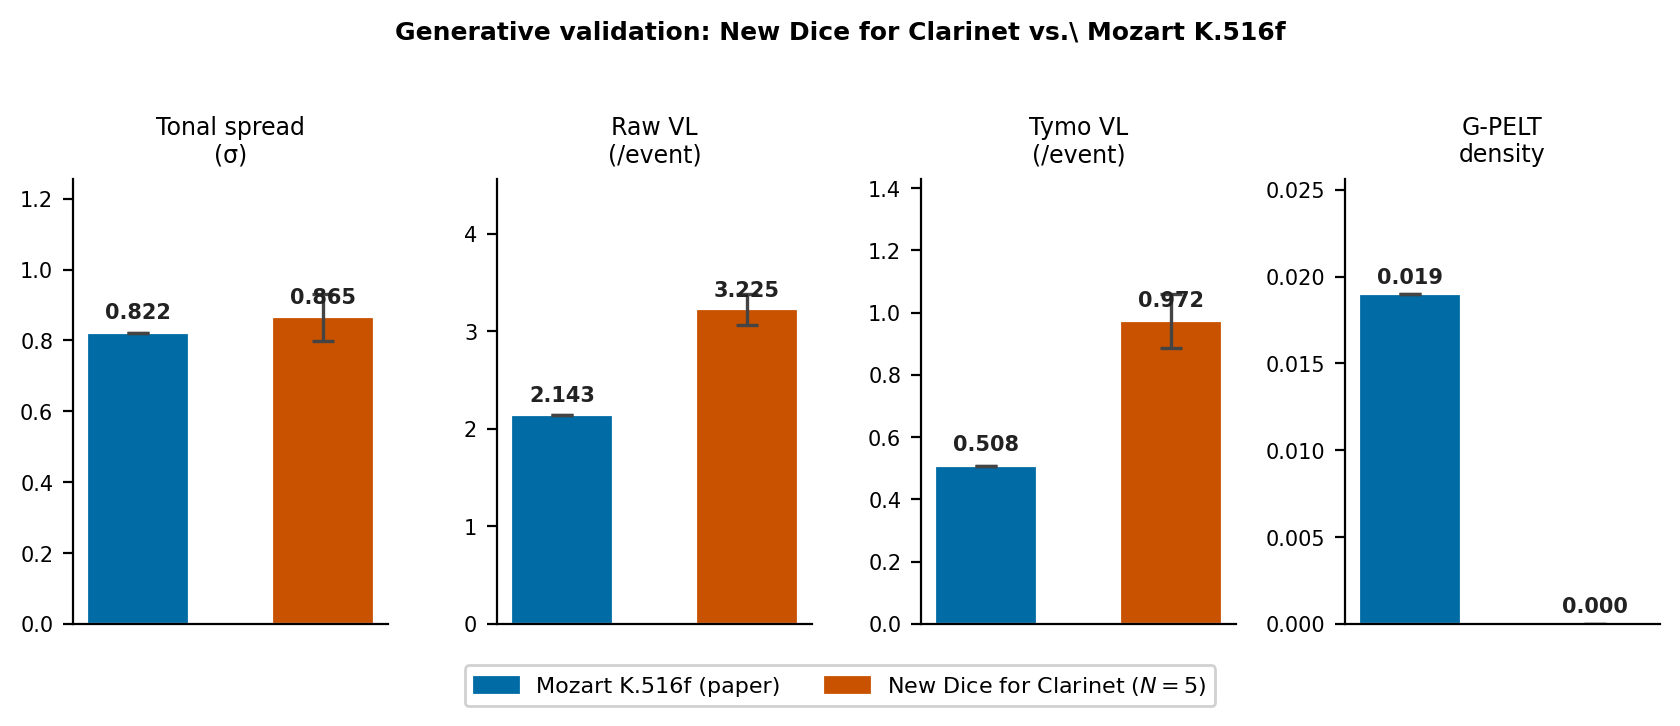

Saved: /content/drive/MyDrive/NEWDiceForClarinet/output/fig_generative_validation.png


In [ ]:
# ══════════════════════════════════════════════════════════════════
# Figure: Section 4.7 Generative Validation
# Bar chart: Mozart K.516f vs New Dice (v12 piano)
# 4 metrics: σ, Raw VL, Tymo VL, G-PELT
# ══════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Data ─────────────────────────────────────────────────────────
METRICS   = ['Tonal spread\n(σ)', 'Raw VL\n(/event)', 'Tymo VL\n(/event)', 'G-PELT\ndensity']
MOZART    = [0.822, 2.143, 0.508, 0.019]

# Individual piece values
GEN_PIECES = [
    [0.904, 3.238, 0.906, 0.000],
    [0.803, 3.154, 1.099, 0.000],
    [0.845, 2.970, 0.983, 0.000],
    [0.798, 3.433, 1.023, 0.000],
    [0.973, 3.329, 0.850, 0.000],
]
GEN_MEAN = np.mean(GEN_PIECES, axis=0)
GEN_SD   = np.std(GEN_PIECES,  axis=0)

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(8.5, 3.2))

COLORS = {
    'mozart': '#006BA4',   # blue
    'gen':    '#C85200',   # burnt orange
}

for ax, metric, mval, gval, gsd in zip(axes, METRICS, MOZART, GEN_MEAN, GEN_SD):
    x     = np.array([0, 1])
    vals  = [mval, gval]
    errs  = [0,    gsd]
    bars  = ax.bar(x, vals,
                   color=[COLORS['mozart'], COLORS['gen']],
                   width=0.55,
                   edgecolor='white',
                   linewidth=0.8,
                   yerr=errs,
                   capsize=4,
                   error_kw={'elinewidth': 1.2,
                             'ecolor':     '#444444',
                             'capthick':   1.2})

    # Value labels on bars
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + gsd * 0.15 + ax.get_ylim()[1] * 0.02,
                f'{val:.3f}',
                ha='center', va='bottom',
                fontsize=7.5, fontweight='bold', color='#222222')

    ax.set_xticks([])
    ax.set_title(metric, fontsize=8.5, pad=6)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=7.5)

    # Start y-axis at 0
    ax.set_ylim(0, max(mval, gval + gsd) * 1.35)

# ── Legend ────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=COLORS['mozart'], label='Mozart K.516f (paper)'),
    mpatches.Patch(color=COLORS['gen'],    label='New Dice for Clarinet ($N=5$)'),
]
fig.legend(handles=legend_patches,
           loc='lower center',
           ncol=2,
           fontsize=8,
           framealpha=0.9,
           bbox_to_anchor=(0.5, -0.08))

fig.suptitle('Generative validation: New Dice for Clarinet vs.\ Mozart K.516f',
             fontsize=9, fontweight='bold', y=1.01)

plt.tight_layout()

OUT = '/content/drive/MyDrive/NEWDiceForClarinet/output/fig_generative_validation.png'
plt.savefig(OUT, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {OUT}")